In [1]:
import os
import os
os.environ["PROJ_DATA"] = "/user/home/al18709/breathe/.pixi/envs/default/share/proj"

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import geopandas as gpd
import seaborn as sns
import pyreadr


In [2]:
def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def prepare_igr_geodataframe(results, geometry_path):
    geometry_gdf = gpd.read_file(geometry_path)
    geometry_gdf['rgi'] = geometry_gdf['rgi'].astype(str)
    igr_rows = []
    for igr, df in results['igr'].items():
        row = {'rgi': str(igr)}
        for statistic in df.index:
            row[f'{statistic}_mean']  = df.loc[statistic, 'mean']
            row[f'{statistic}_p2.5']  = df.loc[statistic, 'p2.5']
            row[f'{statistic}_p97.5'] = df.loc[statistic, 'p97.5']
        igr_rows.append(row)
    results_df = pd.DataFrame(igr_rows)
    return geometry_gdf.merge(results_df, on='rgi', how='left')


In [3]:
# ============================================================
# DATA LOADING
# ============================================================

polys        = '/bp1/geog-tropical/data/BREATHE/RG2017_rgi_20180911/RG2017_rgi.shp'
polys_states = '/bp1/geog-tropical/data/BREATHE/shapefiles/BR_UF_2022.shp'
gdf_states   = gpd.read_file(polys_states)

macroregion_map = {
    'RO': 'North',    'AC': 'North',     'AM': 'North',       'RR': 'North',
    'PA': 'North',    'AP': 'North',     'TO': 'North',
    'MA': 'Northeast','PI': 'Northeast', 'CE': 'Northeast',   'RN': 'Northeast',
    'PB': 'Northeast','PE': 'Northeast', 'AL': 'Northeast',   'SE': 'Northeast', 'BA': 'Northeast',
    'MT': 'Central-West','MS': 'Central-West','GO': 'Central-West','DF': 'Central-West',
    'SP': 'Southeast','RJ': 'Southeast', 'MG': 'Southeast',   'ES': 'Southeast',
    'PR': 'South',    'SC': 'South',     'RS': 'South'
}
gdf_states['macroregion'] = gdf_states['SIGLA_UF'].map(macroregion_map)
macro = gdf_states.dissolve(by='macroregion')

results     = load_results('/bp1/geog-tropical/data/BREATHE/results/results_100M.pkl')
results_gdf = prepare_igr_geodataframe(results, geometry_path=polys)

uf_code_to_region = {
    11: 'North', 12: 'North', 13: 'North', 14: 'North', 15: 'North', 16: 'North', 17: 'North',
    21: 'Northeast', 22: 'Northeast', 23: 'Northeast', 24: 'Northeast', 25: 'Northeast',
    26: 'Northeast', 27: 'Northeast', 28: 'Northeast', 29: 'Northeast',
    31: 'Southeast', 32: 'Southeast', 33: 'Southeast', 35: 'Southeast',
    41: 'South', 42: 'South', 43: 'South',
    50: 'Central-West', 51: 'Central-West', 52: 'Central-West', 53: 'Central-West',
}
results_gdf['Region'] = results_gdf['rgi'].apply(
    lambda x: uf_code_to_region.get(int(str(x)[:2]), None)
)
gdf_missing = results_gdf[results_gdf['attributable_mortality_per_100k_mean'].isna()]


In [ ]:
# load in data
results_gdf['rgi'] = results_gdf['rgi'].astype(str)
results_gdf['attributable_mortality_per_100k_mean'] = results_gdf['attributable_mortality_per_person_year_mean'] * 1000000
results_gdf['attributable_mortality_per_100k_p2.5'] = results_gdf['attributable_mortality_per_person_year_p2.5'] * 1000000
results_gdf['attributable_mortality_per_100k_p97.5'] = results_gdf['attributable_mortality_per_person_year_p97.5'] * 1000000

In [10]:


# --- Elevation ---
# df_elev = pd.read_parquet('/bp1/geog-tropical/data/BREATHE/igr_elevation.parquet')
# df_elev_grouped = df_elev.groupby('rgi', as_index=False)['mean_elevation'].mean()
# df_merged = pd.merge(df_elev, gdf[['rgi','geometry']], on='rgi', how='left')
# df_gdf_state = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=gdf.crs)
# mortality = mortality.merge(df_gdf_state[['rgi','mean_elevation','geometry']], on='rgi', how='left')


# --- Population density ---
population_df = pd.read_parquet(f"/bp1/geog-tropical/data/BREATHE/igr_population.parquet")
population_df['rgi'] = population_df['rgi'].astype(str)


# --- Heatwave ---
hw = pd.read_csv('hw.csv')
hw['rgi'] = hw['rgi'].astype(str)
hw['number_of_heatwaves_per_year'] = hw['daily_mean_temperature']  # check if this is correct
results_gdf = results_gdf.merge(hw[['rgi','number_of_heatwaves_per_year']], on='rgi', how='left')

# --- extreme heat ---
eh = pd.read_csv('extreme_heat_days.csv')
eh['rgi'] = eh['rgi'].astype(str)
results_gdf = results_gdf.merge(eh[['rgi','additional_eh_days']], on='rgi', how='left')

# --- Temperature anomaly ---
temp_anom = pd.read_csv('anom_temp.csv')
temp_anom['rgi'] = temp_anom['rgi'].astype(str)
results_gdf = results_gdf.merge(temp_anom[['rgi','temperature_anomaly']], on='rgi', how='left')

# --- Vegetation ---
ndvi = pd.read_csv('NDVI-MODIS-16-Day-L3-Global-250m-DATE-IGR.csv', delimiter=';')
ndvi['rgi'] = ndvi['rgi'].astype(str)
ndvi['vegetation_cover'] = ndvi.drop(columns=['Unnamed: 0','rgi']).mean(axis=1)
results_gdf = results_gdf.merge(ndvi[['rgi','vegetation_cover']], on='rgi', how='left')

# --- Relative Humidity ---
rh = pd.read_parquet('RH_BR_DWGD_v_3.2.3_long_IGR.parquet')
mean_rh = rh.groupby('rgi', as_index=False)['daily_relative_humidity'].mean()
mean_rh.rename(columns={'daily_relative_humidity':'mean_rh'}, inplace=True)
mean_rh['rgi'] = mean_rh['rgi'].astype(str)
results_gdf = results_gdf.merge(mean_rh, on='rgi', how='left')

# --- Temperature variation ---
var = pd.read_parquet('mean_temp_BR_DWGD_v_3.2.3_long_IGR (1).parquet')
std_temp = var.groupby('rgi', as_index=False)['daily_mean_temperature'].std()
std_temp.rename(columns={'daily_mean_temperature':'std_temp'}, inplace=True)
std_temp['rgi'] = std_temp['rgi'].astype(str)
results_gdf = results_gdf.merge(std_temp, on='rgi', how='left')

In [11]:
# --- hospitalisation data ---

hosp = pd.read_excel('data_census2022_hospitalization.xlsx')
hosp.rename(columns={
    'cod7': 'code7',
    'NM_MUN': 'municipality_name',
    'areatotal_2022': 'total_area_2022',
    'Pop_Total_2022': 'total_population_2022',
    'Pop_0A14': 'population_0_to_14',
    'Pop_65emais': 'population_65_and_over',
    'razao_depend': 'dependency_ratio',
    'densidade': 'population_density',
    'AreaUrbanizadaKm_2019': 'urbanized_area_km2_2019',
    'perc_rede_esgoto_fossa_2022': 'sewage_coverage_percent_2022',
    'Total_dom_2022': 'total_households_2022',
    'Dom_rede,geral_agua_2022': 'households_water_network_2022',
    'Perc_dom_rede_abast_agua_2022': 'household_water_supply_percent_2022',
    'PIB2021': 'gdp_2021',
    'cod6': 'code6',
    'cobertura_aps_mun': 'primary_care_coverage',
    'tot_internacao2022': 'total_hospitalizations_2022',
    'Tot_internacaoCapI_2022': 'hospitalizations_level1_2022',
    'totalbitos2022': 'total_deaths_2022',
    'leitosInternacao2022': 'inpatient_beds_2022',
    'leitoscomplementares2022': 'supplementary_beds_2022',
    'leitosobstetricos': 'obstetric_beds',
    'taxamorte': 'mortality_rate',
    'taxaIntTotal': 'total_hospitalization_rate',
    'taxaIntCap1': 'hospitalization_rate_level1',
    'leitosTotal': 'total_beds',
    'taxaocupacao': 'occupancy_rate',
    'PM2,5': 'pm2_5'
}, inplace=True)

igr_mun = pd.read_csv('rgi_mun.csv')
hosp['code7'] = hosp['code7'].astype(str).str.zfill(7)
# igr_mun['cod_rgi'] = igr_mun['cod_rgi'].astype(str).str.zfill(7)
igr_mun['cod_rgi'] = igr_mun['cod_rgi'].astype(str).str.lstrip('0')
igr_mun['CD_GEOCODI'] = igr_mun['CD_GEOCODI'].astype(str).str.zfill(7)

# Merge the datasets on municipality code
merged = hosp.merge(igr_mun[['CD_GEOCODI', 'cod_rgi']], left_on='code7', right_on='CD_GEOCODI', how='left').drop(columns='CD_GEOCODI')

# Define aggregation functions
agg_dict = {
    'total_area_2022': 'sum',
    'total_population_2022': 'sum',
    'population_0_to_14': 'sum',
    'population_65_and_over': 'sum',
    'urbanized_area_km2_2019': 'sum',
    'total_deaths_2022': 'sum',
    'inpatient_beds_2022': 'sum',
    'supplementary_beds_2022': 'sum',
    'obstetric_beds': 'sum',
    'total_beds': 'sum',

    # Weighted averages
    'dependency_ratio': lambda x: (x * merged.loc[x.index, 'total_population_2022']).sum() / merged.loc[x.index, 'total_population_2022'].sum(),
    'population_density': lambda x: (x * merged.loc[x.index, 'total_area_2022']).sum() / merged.loc[x.index, 'total_area_2022'].sum(),
    'sewage_coverage_percent_2022': lambda x: (x * merged.loc[x.index, 'total_population_2022']).sum() / merged.loc[x.index, 'total_population_2022'].sum(),
    'mortality_rate': lambda x: (x * merged.loc[x.index, 'total_population_2022']).sum() / merged.loc[x.index, 'total_population_2022'].sum(),
    'total_hospitalization_rate': lambda x: (x * merged.loc[x.index, 'total_population_2022']).sum() / merged.loc[x.index, 'total_population_2022'].sum(),
    'hospitalization_rate_level1': lambda x: (x * merged.loc[x.index, 'total_population_2022']).sum() / merged.loc[x.index, 'total_population_2022'].sum(),
    'occupancy_rate': lambda x: (x * merged.loc[x.index, 'total_beds']).sum() / merged.loc[x.index, 'total_beds'].sum(),
    'pm2_5': lambda x: (x * merged.loc[x.index, 'total_population_2022']).sum() / merged.loc[x.index, 'total_population_2022'].sum()
}

# Group by IGR and aggregate
igr_agg = merged.groupby(['cod_rgi']).agg(agg_dict).reset_index()
igr_agg.rename(columns={'cod_rgi': 'rgi'},inplace=True)
igr_agg['rgi'] = igr_agg['rgi'].astype(str)
results_gdf = results_gdf.merge(igr_agg[['rgi','total_area_2022', 'total_population_2022',
       'population_0_to_14', 'population_65_and_over',
       'urbanized_area_km2_2019', 'total_deaths_2022', 'inpatient_beds_2022',
       'supplementary_beds_2022', 'obstetric_beds', 'total_beds',
       'dependency_ratio', 'population_density',
       'sewage_coverage_percent_2022', 'mortality_rate',
       'total_hospitalization_rate', 'hospitalization_rate_level1',
       'occupancy_rate', 'pm2_5']], on='rgi', how='left')

In [12]:
# --- IGR descriptive data ---

descriptives = pd.read_csv('rgi_descriptives_20250809.csv')
descriptives.rename(columns={'COD_RGI': 'rgi'},inplace=True)
descriptives['rgi'] = descriptives['rgi'].astype(str)
results_gdf = results_gdf.merge(descriptives[['rgi','n_municipalities',
       'total_population_2017', 'population_60plus_2017',
       'population_under60_2017', 'indigenous_total_2010',
       'indigenous_total_2022', 'total_deaths', 'deaths_60plus',
       'deaths_under60', 'tmean_min', 'tmean_mean', 'tmean_max', 'tmean_q1',
       'tmean_q3', 'tmean_IQR', 'tmean_range', 'tmean_pw_min', 'tmean_pw_mean',
       'tmean_pw_max', 'tmean_pw_q1', 'tmean_pw_q3', 'tmean_pw_IQR',
       'tmean_pw_range', 'ndvi_rgi_category', 'ndvi_max_period',
       'ndvi_min_period', 'ndvi_mean_annual_mean', 'ndvi_max_annual_mean',
       'ndvi_min_annual_mean', 'n_munis_with_population_2017', 'rh_min',
       'rh_mean', 'rh_max', 'rh_q1', 'rh_q3', 'rh_IQR', 'rh_pw_min',
       'rh_pw_mean', 'rh_pw_max', 'rh_pw_q1', 'rh_pw_q3', 'rh_pw_IQR']], on='rgi', how='left')

In [13]:
# n_deaths = pd.read_excel('/user/home/al18709/breathe/data_analysis/Total_deaths_mean_time_series.xlsx')
# n_deaths.rename(columns={'COD_IGR': 'rgi'},inplace=True)
# n_deaths['rgi'] = n_deaths['rgi'].astype(str)

# --- total obitos data ---

n_deaths = pd.read_excel('/user/home/al18709/breathe/data_analysis/Results_COHORT_noRH_tas_ACCESS-CM2_r1i1p1f1.xlsx')
n_deaths.rename(columns={'COD_RGI': 'rgi'},inplace=True)
n_deaths['rgi'] = n_deaths['rgi'].astype(str)

results_gdf = results_gdf.merge(n_deaths[['rgi','total_obitos']], on='rgi', how='left')
results_gdf['n_deaths'] = results_gdf['total_obitos']

# mortality = mortality.merge(n_deaths[['rgi','total_deaths']], on='rgi', how='left')
# mortality['n_deaths'] = mortality['total_deaths']

pca = pd.read_excel('rgi_descriptives_20250819_selected.xlsx')


In [14]:
# --- svi data ---

svi = pd.read_excel('SVI and dimensions.xlsx')
svi.rename(columns={'COD_IGR': 'rgi'},inplace=True)
svi['rgi'] = svi['rgi'].astype(str)

results_gdf = results_gdf.merge(svi[['rgi', 'SVI_2010', 'SVI Urban Infrastructure 2010',
       'SVI Human Capital 2010', 'SVI Income and Work 2010', 'SVI_diff',
       'SVI Urban Infrastructure diff', 'SVI Human Capital diff',
       'SVI Income and Work diff']], on='rgi', how='left')


In [15]:
# --- dados data ---

dados = pd.read_excel('dados_IVS.xlsx')

dados = dados.rename(columns={
    "UF": "State Abbreviation",
    "Nome da UF": "State Name",
    "Município": "Municipality Code",
    "Nome do Município": "Municipality Name",
    "Município com 6 dígitos": "Municipality (6 digits)",
    "Ano": "Year",
    "IVS": "SVI",
    "IVS Infraestrutura Urbana": "SVI Urban Infrastructure",
    "IVS Capital Humano": "SVI Human Capital",
    "IVS Renda e Trabalho": "SVI Income and Work",
    "% de pessoas em domicílios com abastecimento de água e esgotamento sanitário inadequados": "% Households with inadequate water & sanitation",
    "% da população que vive em domicílios urbanos sem o serviço de coleta de lixo": "% Urban households without garbage collection",
    "% de pessoas que vivem em domicílios com renda per capita inferior a meio salário mínimo (de 2010) e que gastam mais de uma hora até o trabalho": "% Low-income (≤½ min wage, 2010) commuting >1h",
    "Mortalidade até 1 ano de idade": "Infant mortality (<1 year)",
    "% de crianças de 0 a 5 anos que não frequentam a escola": "% Children 0–5 not in school",
    "% de pessoas de 6 a 14 anos que não frequentam a escola": "% People 6–14 not in school",
    "% de mulheres de 10 a 17 anos que tiveram filhos": "% Females 10–17 with children",
    "% de mães chefes de família, sem fundamental completo e com filho menor de 15 anos de idade": "% Female heads w/o primary, child <15",
    "Taxa de analfabetismo da população de 15 anos ou mais de idade": "Illiteracy rate (15+)",
    "% de crianças que vivem em domicílios em que nenhum dos moradores tem o ensino fundamental completo": "% Children in hh w/o completed primary",
    "% de pessoas de 15 a 24 anos que não estudam, não trabalham e possuem renda domiciliar per capita igual ou inferior a meio salário mínimo (de 2010)": "% Youth 15–24 NEET ≤½ min wage (2010)",
    "Porcentagem de pessoas com renda domiciliar per capita igual ou inferior a meio salário mínimo (de 2010)": "% People ≤½ min wage (2010)",
    "Taxa de desocupação da população de 18 anos ou mais de idade": "Unemployment rate (18+)",
    "% de pessoas de 18 anos ou mais sem fundamental completo e em ocupação informal": "% Informal workers 18+ w/o primary",
    "% de pessoas em domicílios com renda per capita inferior a meio salário mínimo (de 2010) e dependentes de idosos": "% Low-income hh dependent on elderly",
    "Taxa de atividade das pessoas de 10 a 14 anos de idade": "Activity rate (10–14)",
    "IDHM": "HDI",
    "IDHM Longevidade": "HDI Longevity",
    "IDHM Educação": "HDI Education",
    "IDHM Renda": "HDI Income",
    "Esperança de vida ao nascer": "Life expectancy at birth",
    "Subíndice de escolaridade - IDHM Educação": "HDI Education - Schooling subindex",
    "% de 18 anos ou mais com fundamental completo": "% 18+ completed primary",
    "Subíndice de frequência escolar - IDHM Educação": "HDI Education - Attendance subindex",
    "% de 5 a 6 anos na escola": "% Children 5–6 in school",
    "% de 11 a 13 anos nos anos finais do fundamental ou com fundamental completo": "% 11–13 in final primary or completed",
    "% de 15 a 17 anos com fundamental completo": "% 15–17 completed primary",
    "% de 18 a 20 anos com médio completo": "% 18–20 completed secondary",
    "Renda per capita": "Per capita income",
    "Prosperidade Social": "Social Prosperity",
    "População total": "Total population",
    "Mortalidade até 5 anos de idade": "Under-5 mortality",
    "Razão de dependência": "Dependency ratio",
    "Taxa de fecundidade total": "Total fertility rate",
    "Taxa de envelhecimento": "Aging rate",
    "População vulnerável de 15 a 24 anos": "Vulnerable population 15–24",
    "Mulheres chefes de família e com filhos menores de 15 anos": "Female heads with children <15",
    "População ocupada vulnerável à pobreza que retorna diariamente do trabalho": "Vulnerable employed commuting daily",
    "População em domicílios vulneráveis e com idoso": "Population in vulnerable hh with elderly",
    "População de até 1 ano": "Population <1 year",
    "População de 1 a 3 anos": "Population 1–3",
    "População de 4 anos": "Population 4",
    "População de 5 anos": "Population 5",
    "População de 6 anos": "Population 6",
    "População de 6 a 10 anos": "Population 6–10",
    "População de 6 a 17 anos": "Population 6–17",
    "População de 11 a 13 anos": "Population 11–13",
    "População de 11 a 14 anos": "Population 11–14",
    "População de 12 a 14 anos": "Population 12–14",
    "População de 15 anos ou mais": "Population 15+",
    "População de 15 a 17 anos": "Population 15–17",
    "População de 15 a 24 anos": "Population 15–24",
    "População de 16 a 18 anos": "Population 16–18",
    "População de 18 anos ou mais": "Population 18+",
    "População de 18 a 20 anos": "Population 18–20",
    "População de 18 a 24 anos": "Population 18–24",
    "População de 19 a 21 anos": "Population 19–21",
    "População de 25 anos ou mais": "Population 25+",
    "População de 65 anos ou mais": "Population 65+",
    "PEA - 10 anos ou mais": "EAP (10+)",
    "PEA - 10 a 14 anos": "EAP (10–14)",
    "PEA - 15 a 17 anos": "EAP (15–17)",
    "PEA - 18 anos ou mais": "EAP (18+)",
    "% da população em domicílios com energia elétrica": "% Households with electricity",
    "% da população em domicílios com densidade > 2": "% Households density >2 per room",
    "Taxa de analfabetismo - 18 anos ou mais": "Illiteracy rate (18+)",
    "Taxa de analfabetismo - 25 anos ou mais": "Illiteracy rate (25+)",
    "Renda per capita dos vulneráveis à pobreza": "Per capita income - vulnerable",
    "% da renda proveniente de rendimentos do trabalho": "% Income from labor earnings",
    "Índice de Gini": "Gini Index",
    "% de empregados com carteira - 18 anos ou mais": "% Employees w/ contract (18+)",
    "% de empregados sem carteira - 18 anos ou mais": "% Employees w/o contract (18+)",
    "% de trabalhadores do setor público - 18 anos ou mais": "% Public sector workers (18+)",
    "% de trabalhadores por conta própria - 18 anos ou mais": "% Self-employed (18+)",
    "% de empregadores - 18 anos ou mais": "% Employers (18+)",
    "Grau de formalização dos ocupados - 18 anos ou mais": "Formalization degree (18+ employed)",
    "% dos ocupados com fundamental completo - 18 anos ou mais": "% Employed 18+ w/ primary",
    "% dos ocupados com médio completo - 18 anos ou mais": "% Employed 18+ w/ secondary",
    "% dos ocupados com superior completo - 18 anos ou mais": "% Employed 18+ w/ higher ed",
    "Rendimento médio dos ocupados - 18 anos ou mais": "Avg income employed (18+)",
    "% dos ocupados sem rendimento - 18 anos ou mais": "% Employed 18+ w/o income"
})

dados['Municipality Code'] = dados['Municipality Code'].astype(str).str.zfill(7)
merged_d = dados.merge(igr_mun[['CD_GEOCODI', 'cod_rgi']], left_on='Municipality Code', right_on='CD_GEOCODI', how='left').drop(columns='CD_GEOCODI')



# Define aggregation functions
agg_dict = {
       
        'Life expectancy at birth': lambda x: (x * merged_d.loc[x.index, 'Total population']).sum() /
                                          merged_d.loc[x.index, 'Total population'].sum(),

    'Per capita income': lambda x: (x * merged_d.loc[x.index, 'Total population']).sum() /
                                   merged_d.loc[x.index, 'Total population'].sum(),

    'Vulnerable population 15–24': lambda x: (x * merged_d.loc[x.index, 'Population 15–24']).sum() /
                                             merged_d.loc[x.index, 'Population 15–24'].sum(),
        'Vulnerable employed commuting daily': 'sum',
        'Female heads with children <15':'sum',
        'Population in vulnerable hh with elderly': 'sum',
        'Population <1 year': 'sum',
        'Population 1–3': 'sum', 
        'Population 4': 'sum', 
        'Population 5': 'sum', 
        'Population 6': 'sum',
        'Population 6–10': 'sum', 
        'Population 6–17': 'sum', 
        'Population 11–13': 'sum',
        'Population 11–14': 'sum', 
        'Population 12–14': 'sum', 
        'Population 15+': 'sum',
        'Population 15–17': 'sum', 
        'Population 15–24': 'sum', 
        'Population 16–18': 'sum',
        'Population 18+': 'sum', 
        'Population 18–20': 'sum', 
        'Population 18–24': 'sum',
        'Population 19–21': 'sum', 
        'Population 25+': 'sum', 
        'Population 65+': 'sum', 
        'EAP (10+)': 'sum',
        'EAP (10–14)': 'sum', 
        'EAP (15–17)': 'sum', 
        'EAP (18+)': 'sum',

}
       
       
# Group by IGR and aggregate
igr_agg_d = merged_d.groupby(['cod_rgi']).agg(agg_dict).reset_index()


igr_agg_d.rename(columns={'cod_rgi': 'rgi'},inplace=True)
igr_agg_d['rgi'] = igr_agg_d['rgi'].astype(str)

results_gdf = results_gdf.merge(igr_agg_d[['rgi','Life expectancy at birth','Per capita income','Vulnerable population 15–24','Vulnerable employed commuting daily',
                                             'Female heads with children <15',
        'Population in vulnerable hh with elderly',
        'Population <1 year',
        'Population 1–3', 
        'Population 4', 
        'Population 5', 
        'Population 6',
        'Population 6–10', 
        'Population 6–17', 
        'Population 11–13',
        'Population 11–14', 
        'Population 12–14', 
        'Population 15+',
        'Population 15–17', 
        'Population 15–24', 
        'Population 16–18',
        'Population 18+', 
        'Population 18–20', 
        'Population 18–24',
        'Population 19–21', 
        'Population 25+', 
        'Population 65+', 
        'EAP (10+)',
        'EAP (10–14)', 
        'EAP (15–17)', 
        'EAP (18+)']], on='rgi', how='left')



In [16]:
# --- pm2.5 data ---

pm25 = pd.read_csv('IGR_PM25_summary_pop_weighted.csv')

pm25['rgi'] = pm25['rgi'].astype(str)

results_gdf = results_gdf.merge(pm25[['rgi','pm25_period_mean_pop_weighted',
       'pm25_annual_min_pop_weighted', 'pm25_annual_max_pop_weighted',
       'pm25_annual_q25_pop_weighted', 'pm25_annual_q75_pop_weighted',
       'pm25_annual_iqr_pop_weighted', 'pm25_annual_p75_pop_weighted',
       'months_min_year', 'years_above_5', 'years_above_10', 'years_above_15',
       'years_above_25', 'years_above_35', '50perc_year_above_5',
       '50perc_year_above_10', '50perc_year_above_15', '50perc_year_above_25',
       '50perc_year_above_35', '75perc_year_above_5', '75perc_year_above_10',
       '75perc_year_above_15', '75perc_year_above_25', '75perc_year_above_35']], on='rgi', how='left')



In [17]:
# --- minimum mortality data ---

mmt = pd.read_excel('/user/home/al18709/breathe/data_analysis/MMT_BLUP_COHORT_lag5_knots_p10_90_df4_noRH.xlsx')
# mmt = pyreadr.read_r('two_stage_TS_RGI_cohort.RData')['mmt_blup']
mmt.rename(columns={'COD_RGI': 'rgi'},inplace=True)
mmt['rgi'] = mmt['rgi'].astype(str)
results_gdf = results_gdf.merge(mmt[['rgi','MMT']], on='rgi', how='left')

In [19]:
# remove missing IGRS

# find the igrs where mortality is nan
nan_mortality = results_gdf[results_gdf['attributable_mortality_per_100k_mean'].isna()]
results_gdf.drop(nan_mortality.index, inplace=True)

In [20]:
# all regions, detectible by deaths normalised - AF
detectible = results_gdf.copy()
not_shaded = results_gdf[(results_gdf['attributable_fraction_p2.5'] > 0)]
shaded = results_gdf[(results_gdf['attributable_fraction_p2.5'] <= 0)]
detectible_2 = detectible[((detectible.attributable_fraction_mean <= np.percentile(detectible['attributable_fraction_mean'],20)) & (detectible.attributable_fraction_mean > 0))]
detectible_3 = detectible[((detectible.attributable_fraction_mean <= np.percentile(detectible['attributable_fraction_mean'],40)) & (detectible.attributable_fraction_mean > np.percentile(detectible['attributable_fraction_mean'],20)))]
detectible_4 = detectible[((detectible.attributable_fraction_mean <= np.percentile(detectible['attributable_fraction_mean'],60)) & (detectible.attributable_fraction_mean > np.percentile(detectible['attributable_fraction_mean'],40)))]
detectible_5 = detectible[((detectible.attributable_fraction_mean <= np.percentile(detectible['attributable_fraction_mean'],80)) & (detectible.attributable_fraction_mean > np.percentile(detectible['attributable_fraction_mean'],60)))]
detectible_6 = detectible[((detectible.attributable_fraction_mean <= np.percentile(detectible['attributable_fraction_mean'],100)) & (detectible.attributable_fraction_mean > np.percentile(detectible['attributable_fraction_mean'],80)))]
print(len(detectible_2))
print(len(detectible_3))
print(len(detectible_4))
print(len(detectible_5))
print(len(detectible_6))

99
99
98
99
99


In [21]:
# all regions, detectible by deaths per 100000 - AN
detectible = results_gdf.copy()
not_shaded = results_gdf[(results_gdf['attributable_mortality_per_100k_p2.5'] > 0)]
shaded = results_gdf[(results_gdf['attributable_mortality_per_100k_p2.5'] <= 0)]
detectible_2 = detectible[((detectible.attributable_mortality_per_100k_mean <= np.percentile(detectible['attributable_mortality_per_100k_mean'],20)) & (detectible.attributable_mortality_per_100k_mean > 0))]
detectible_3 = detectible[((detectible.attributable_mortality_per_100k_mean <= np.percentile(detectible['attributable_mortality_per_100k_mean'],40)) & (detectible.attributable_mortality_per_100k_mean > np.percentile(detectible['attributable_mortality_per_100k_mean'],20)))]
detectible_4 = detectible[((detectible.attributable_mortality_per_100k_mean <= np.percentile(detectible['attributable_mortality_per_100k_mean'],60)) & (detectible.attributable_mortality_per_100k_mean > np.percentile(detectible['attributable_mortality_per_100k_mean'],40)))]
detectible_5 = detectible[((detectible.attributable_mortality_per_100k_mean <= np.percentile(detectible['attributable_mortality_per_100k_mean'],80)) & (detectible.attributable_mortality_per_100k_mean > np.percentile(detectible['attributable_mortality_per_100k_mean'],60)))]
detectible_6 = detectible[((detectible.attributable_mortality_per_100k_mean <= np.percentile(detectible['attributable_mortality_per_100k_mean'],100)) & (detectible.attributable_mortality_per_100k_mean > np.percentile(detectible['attributable_mortality_per_100k_mean'],80)))]
print(len(detectible_2))
print(len(detectible_3))
print(len(detectible_4))
print(len(detectible_5))
print(len(detectible_6))

99
99
98
99
99


In [23]:
polys = '/bp1/geog-tropical/data/BREATHE/shapefiles/BR_UF_2022.shp'
gdf_states = gpd.read_file(polys)

# Mapping of UF codes to macroregions
macroregion_map = {
    'RO': 'North', 'AC': 'North', 'AM': 'North', 'RR': 'North', 'PA': 'North', 'AP': 'North', 'TO': 'North',
    'MA': 'Northeast', 'PI': 'Northeast', 'CE': 'Northeast', 'RN': 'Northeast', 'PB': 'Northeast',
    'PE': 'Northeast', 'AL': 'Northeast', 'SE': 'Northeast', 'BA': 'Northeast',
    'MT': 'Central-West', 'MS': 'Central-West', 'GO': 'Central-West', 'DF': 'Central-West',
    'SP': 'Southeast', 'RJ': 'Southeast', 'MG': 'Southeast', 'ES': 'Southeast',
    'PR': 'South', 'SC': 'South', 'RS': 'South'
}

gdf_states["macroregion"] = gdf_states["SIGLA_UF"].map(macroregion_map)
macro = gdf_states.dissolve(by="macroregion")

polys = '/bp1/geog-tropical/data/BREATHE/RG2017_rgi_20180911/RG2017_rgi.shp'
gdf = gpd.read_file(polys)

/tmp/ipykernel_845479/2761313617.py:218: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_845479/2761313617.py:218: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_845479/2761313617.py:218: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_845479/2761313617.py:218: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_845479/2761313617.py:272: UserWarning: This figure includes Axes that

medeian1 3.068706860734725
medeian2 3.233596524734296
medeian3 3.2200145668315177
medeian4 3.183430752683848
medeian5 3.255997865653439
medeian1 1.1403808500000001
medeian2 1.2215195
medeian3 1.2010908
medeian4 1.3661385
medeian5 1.699913
medeian1 52.84364294760967
medeian2 61.76821180625361
medeian3 59.63028179573267
medeian4 62.780808304182926
medeian5 56.45254823221156
medeian1 11.5
medeian2 12.9
medeian3 12.85
medeian4 14.9
medeian5 16.1


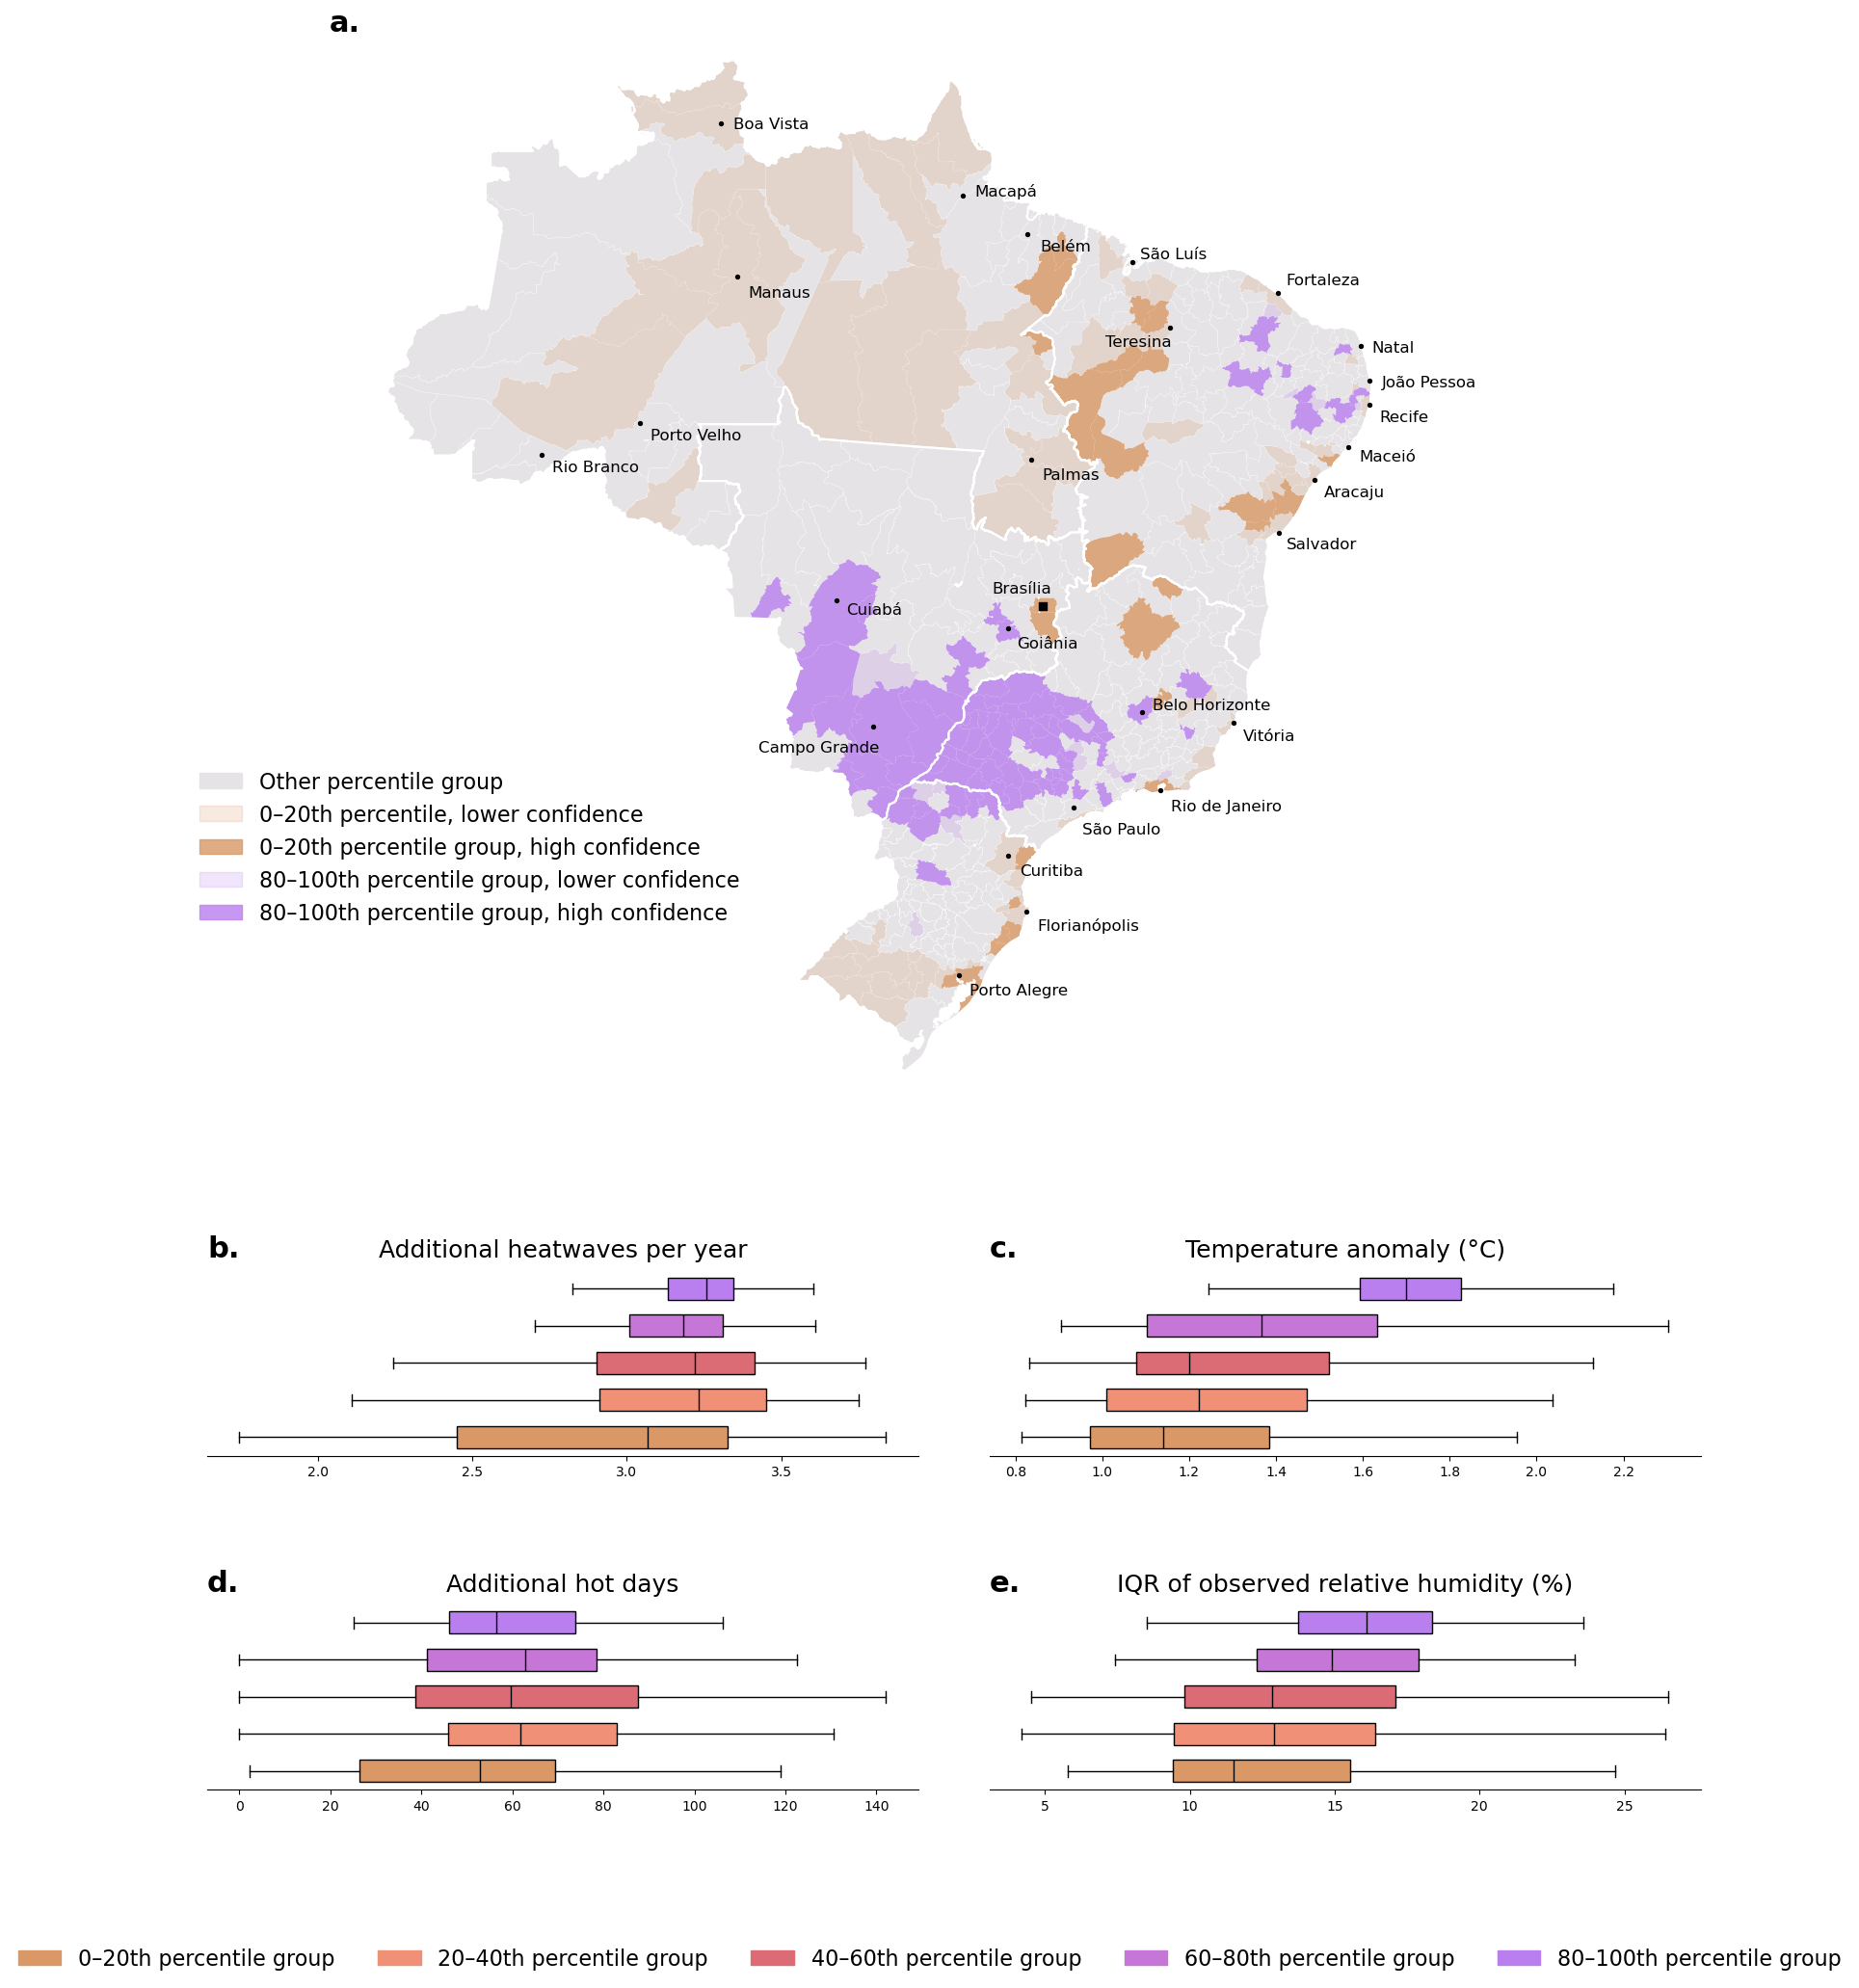

In [25]:
# gdf_d2 = gdf[gdf.rgi.isin(detectible_2.rgi)]
# gdf_d6 = gdf[gdf.rgi.isin(detectible_6.rgi)]

# First, ensure mortality has the rgi column to merge on
gdf_d2 = gdf[gdf.rgi.isin(detectible_2.rgi)]
gdf_d6 = gdf[gdf.rgi.isin(detectible_6.rgi)]

# Filter for non-shaded (detectable)
gdf_d2_not_shaded = gdf_d2[gdf_d2.rgi.isin(not_shaded.rgi)]
gdf_d6_not_shaded = gdf_d6[gdf_d6.rgi.isin(not_shaded.rgi)]

gdf_d2_shaded = gdf_d2[gdf_d2.rgi.isin(shaded.rgi)]
gdf_d6_shaded = gdf_d6[gdf_d6.rgi.isin(shaded.rgi)]

# ---- INPUT DATA ----
variables = [
    'number_of_heatwaves_per_year', 
    'temperature_anomaly',
    'additional_eh_days',
    'rh_IQR',
    
]

titles = [
    'Additional heatwaves per year', 
    'Temperature anomaly (°C)',
    'Additional hot days',
    'IQR of observed relative humidity (%)',
]

dfs = {
    # 'detectible': detectible_1,
    '0-20': detectible_2,
    '20-40': detectible_3,
    '40-60': detectible_4,
    '60-80': detectible_5,
    '80-100': detectible_6,
}

colors = {
    # 'detectible': "#eaca7a",
    '0-20': "#d99865",
    '20-40': "#f09177",
    '40-60': "#db6c75",
    '60-80': "#c576d6",
    '80-100': "#ba7fee",

}

# ---- FIGURE SETUP ----
fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[6, 1, 1], hspace=0.3, wspace=0.1)

# ---- MAP PLOT (TOP ROW, FULL WIDTH) ----
ax_map = fig.add_subplot(gs[0, :])

# ---- add city labels ----
size = 8
fontsize = 12
# Acre
ax_map.scatter(-67.809, -9.974, color='black', s=size,zorder=500)
ax_map.annotate('Rio Branco', xy=(-67.4, -10.6), xycoords='data', fontsize=fontsize)

# Alagoas
ax_map.scatter(-35.735, -9.666, color='black', s=size,zorder=500)
ax_map.annotate('Maceió', xy=(-35.3, -10.2), xycoords='data', fontsize=fontsize)

# Amapá
ax_map.scatter(-51.050, 0.034, color='black', s=size,zorder=500)
ax_map.annotate('Macapá', xy=(-50.6, -0.6 + 0.6), xycoords='data', fontsize=fontsize)

# Amazonas
ax_map.scatter(-60.021, -3.122, color='black', s=size,zorder=500)
ax_map.annotate('Manaus', xy=(-59.6, -3.9), xycoords='data', fontsize=fontsize)

# Bahia
ax_map.scatter(-38.505, -12.986, color='black', s=size,zorder=500)
ax_map.annotate('Salvador', xy=(-38.1 -0.1, -13.7 +0.1), xycoords='data', fontsize=fontsize)

# Ceará
ax_map.scatter(-38.529, -3.724, color='black', s=size,zorder=500)
ax_map.annotate('Fortaleza', xy=(-38.1 - 0.1, -3.3 - 0.1), xycoords='data', fontsize=fontsize)

# Distrito Federal
ax_map.scatter(-47.895, -15.807, color='black', marker='s',zorder=500)
ax_map.annotate('Brasília', xy=(-47.4 - 2.5, -16.6 + 1.3), xycoords='data', fontsize=fontsize)

# Espírito Santo
ax_map.scatter(-40.308, -20.315, color='black', s=size,zorder=500)
ax_map.annotate('Vitória', xy=(-39.9, -21.0), xycoords='data', fontsize=fontsize)

# Goiás
ax_map.scatter(-49.264, -16.686, color='black', s=size,zorder=500)
ax_map.annotate('Goiânia', xy=(-48.9, -17.4), xycoords='data', fontsize=fontsize)

# Maranhão
ax_map.scatter(-44.302, -2.530, color='black', s=size,zorder=500)
ax_map.annotate('São Luís', xy=(-43.8 - 0.2, -3.2 + 0.8), xycoords='data', fontsize=fontsize)

# Mato Grosso
ax_map.scatter(-56.098, -15.601, color='black', s=size,zorder=500)
ax_map.annotate('Cuiabá', xy=(-55.6 - 0.1, -16.3 + 0.2), xycoords='data', fontsize=fontsize)

# Mato Grosso do Sul
ax_map.scatter(-54.620, -20.469, color='black', s=size,zorder=600)
ax_map.annotate('Campo Grande', xy=(-54.2 - 5, -21.2-0.25), xycoords='data', fontsize=fontsize)

# Minas Gerais
ax_map.scatter(-43.938, -19.920, color='black', s=size,zorder=500)
ax_map.annotate('Belo Horizonte', xy=(-43.5, -20.7 + 0.9), xycoords='data', fontsize=fontsize)

# Pará
ax_map.scatter(-48.503, -1.455, color='black', s=size,zorder=500)
ax_map.annotate('Belém', xy=(-48.0, -2.1), xycoords='data', fontsize=fontsize)

# Paraíba
ax_map.scatter(-34.864, -7.121, color='black', s=size,zorder=500)
ax_map.annotate('João Pessoa', xy=(-34.4, -7.7+ 0.35), xycoords='data', fontsize=fontsize)

# Paraná
ax_map.scatter(-49.265, -25.428, color='black', s=size,zorder=500)
ax_map.annotate('Curitiba', xy=(-48.8, -26.2), xycoords='data', fontsize=fontsize)

# Pernambuco
ax_map.scatter(-34.883, -8.059, color='black', s=size,zorder=500)
ax_map.annotate('Recife', xy=(-34.5, -8.7), xycoords='data', fontsize=fontsize)

# Piauí
ax_map.scatter(-42.803, -5.090, color='black', s=size,zorder=500)
ax_map.annotate('Teresina', xy=(-42.4 - 3, -5.8), xycoords='data', fontsize=fontsize)

# Rio de Janeiro
ax_map.scatter(-43.189, -22.917, color='black', s=size,zorder=500)
ax_map.annotate('Rio de Janeiro', xy=(-42.8, -23.7), xycoords='data', fontsize=fontsize)

# Rio Grande do Norte
ax_map.scatter(-35.209, -5.795, color='black', s=size,zorder=500)
ax_map.annotate('Natal', xy=(-34.8, -6.4 + 0.4), xycoords='data', fontsize=fontsize)

# Rio Grande do Sul
ax_map.scatter(-51.211, -30.038, color='black', s=size,zorder=500)
ax_map.annotate('Porto Alegre', xy=(-50.8, -30.8), xycoords='data', fontsize=fontsize)

# Rondônia
ax_map.scatter(-63.903, -8.761, color='black', s=size,zorder=500)
ax_map.annotate('Porto Velho', xy=(-63.4 - 0.1, -9.5 + 0.1), xycoords='data', fontsize=fontsize)

# Roraima
ax_map.scatter(-60.673, 2.823, color='black', s=size,zorder=500)
ax_map.annotate('Boa Vista', xy=(-60.2, 2.1 + 0.5), xycoords='data', fontsize=fontsize)

# Santa Catarina
ax_map.scatter(-48.548, -27.595, color='black', s=size,zorder=500)
ax_map.annotate('Florianópolis', xy=(-48.1, -28.3), xycoords='data', fontsize=fontsize)

# São Paulo
ax_map.scatter(-46.638, -23.568, color='black', s=size,zorder=500)
ax_map.annotate('São Paulo', xy=(-46.3, -24.6), xycoords='data', fontsize=fontsize)

# Sergipe
ax_map.scatter(-37.073, -10.947, color='black', s=size,zorder=500)
ax_map.annotate('Aracaju', xy=(-36.7, -11.6), xycoords='data', fontsize=fontsize)

# Tocantins
ax_map.scatter(-48.333, -10.184, color='black', s=size,zorder=500)
ax_map.annotate('Palmas', xy=(-47.9, -10.9), xycoords='data', fontsize=fontsize)


gdf.plot(ax=ax_map, color="#e5e3e5", edgecolor="#fefefe", linewidth=0.2)

gdf_d2_not_shaded.plot(ax=ax_map, color="#d99865", linewidth=0.2, alpha=0.8)
gdf_d6_not_shaded.plot(ax=ax_map, color="#ba7fee", linewidth=0.2, alpha=0.8)

gdf_d2_shaded.plot(ax=ax_map, color="#d99865", linewidth=0.2, alpha=0.2)
gdf_d6_shaded.plot(ax=ax_map, color="#ba7fee", linewidth=0.2, alpha=0.2)

ax_map.set_axis_off()
ax_map.text(0, 1, 'a.', transform=ax_map.transAxes, fontsize=22, fontweight='bold', va='top', ha='left')

macro.plot(ax=ax_map,edgecolor="#ffffff",linewidth=1.5, facecolor="none")


legend_handles_map = [
    mpatches.Patch(color="#e5e3e5", label='Other percentile group'),
    mpatches.Patch(color="#d99865", alpha=0.2, label='0–20th percentile, lower confidence'),
    mpatches.Patch(color="#d99865", alpha=0.8, label='0–20th percentile group, high confidence'),
    mpatches.Patch(color="#ba7fee", alpha=0.2, label='80–100th percentile group, lower confidence'),
    mpatches.Patch(color="#ba7fee", alpha=0.8, label='80–100th percentile group, high confidence'),
]

ax_map.legend(
    handles=legend_handles_map,
    loc='lower left',
    bbox_to_anchor=(-0.12, 0.16),
    frameon=False,
    fontsize=16,
    facecolor='white',
    edgecolor='black',
    framealpha=0.9
)

ax_map.set_axis_off()

# ax_map.set_title("High and low attributable mortality regions", fontsize=10, loc='right', pad=10)

# ---- BOX PLOTS (2 rows, 2 columns) ----
axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[2, 1])
]
labels = ['b.','c.','d.','e.']
i=0
for ax, var, title in zip(axes, variables, titles):
    data = [dfs[group][var].dropna() for group in dfs]

    bp = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        widths=0.6,
        labels=dfs.keys(),
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1),
        showfliers=False
    )
    print('medeian1',pd.Series(data).iloc[0].median())
    print('medeian2',pd.Series(data).iloc[1].median())
    print('medeian3',pd.Series(data).iloc[2].median())
    print('medeian4',pd.Series(data).iloc[3].median())
    print('medeian5',pd.Series(data).iloc[4].median())

    # Color boxes
    for patch, group in zip(bp['boxes'], dfs.keys()):
        patch.set_facecolor(colors[group])
        patch.set_edgecolor('black')

    ax.set_title(title, loc='center', fontsize=18, pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.set_ticks_position('none')
    ax.set_yticklabels([])  # remove y-axis labels
    ax.tick_params(axis='y', length=0)
    ax.grid(False)  # ❌ Disable grid lines

    ax.text(0, 1.19, labels[i], transform=ax.transAxes, fontsize=22, fontweight='bold', va='top', ha='left')
    i = i+1


# ---- LEGEND ----
legend_handles = [
    mpatches.Patch(color="#d99865", label='0–20th percentile group'),
    mpatches.Patch(color="#f09177", label='20–40th percentile group'),
    mpatches.Patch(color="#db6c75", label='40–60th percentile group'),
    mpatches.Patch(color="#c576d6", label='60–80th percentile group'),
    mpatches.Patch(color="#ba7fee", label='80–100th percentile group'),
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.05),
    fontsize=16
)

# ---- FINAL LAYOUT ----
# plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.tight_layout()
plt.savefig('drivers_detectible_IGRs_all_regions_AF.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
def count_by_macroregion(gdf, macro, label=""):
    """
    Count how many regions fall into each macroregion.
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        The GeoDataFrame to analyze
    macro : GeoDataFrame
        The dissolved macroregion GeoDataFrame
    label : str
        Label for printing (optional)
    
    Returns:
    --------
    pd.Series : counts by macroregion
    """
    # Get centroids
    gdf_centroids = gdf.copy()
    gdf_centroids['geometry'] = gdf_centroids.geometry.centroid
    
    # Reset index so macroregion becomes a column
    macro_reset = macro.reset_index()
    
    # Spatial join with macro regions
    gdf_with_macro = gpd.sjoin(gdf_centroids, macro_reset[['geometry', 'macroregion']], how='left', predicate='within')
    
    # Get counts
    counts = gdf_with_macro['macroregion'].value_counts()
    
    # Print results
    if label:
        print(f"\n=== {label} ===")
    print(f"Total regions: {len(gdf_with_macro)}")
    print("\nRegions per macroregion:")
    print(counts)
    
    # Check for any regions that didn't match
    if gdf_with_macro['macroregion'].isna().any():
        print(f"\nWarning: {gdf_with_macro['macroregion'].isna().sum()} regions didn't match any macroregion")
        missing_region = gdf_with_macro[gdf_with_macro['macroregion'].isna()]
        for index, region in missing_region.iterrows():
            print('region is', region)
            region_name = region['nome_rgi']
            print(results_gdf[results_gdf['nome_rgi'] == region_name][['nome_rgi', 'attributable_mortality_per_100k_mean']])
            print(results_gdf[results_gdf['nome_rgi'] == region_name][['nome_rgi', 'attributable_mortality_per_100k_p2.5']])
    return counts



In [ ]:
# Run for all three datasets
counts_all = count_by_macroregion(gdf, macro, "ALL regions (80-100th percentile)")
counts_not_shaded = count_by_macroregion(not_shaded, macro,  "NON-SHADED (detectable signal)")
counts_shaded = count_by_macroregion(shaded, macro,  "SHADED (lower confidence)")

# Summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Total : {counts_all.sum()}")
print(f"Non-shaded: {counts_not_shaded.sum()}")
print(f"Shaded: {counts_shaded.sum()}")

/tmp/ipykernel_2129016/82279583.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid
/tmp/ipykernel_2129016/82279583.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid
/tmp/ipykernel_2129016/82279583.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid



=== ALL regions (80-100th percentile) ===
Total regions: 510

Regions per macroregion:
macroregion
Northeast       154
Southeast       143
South            96
North            62
Central-West     53
Name: count, dtype: int64

region is rgi                                                    330002
nome_rgi                                       Angra dos Reis
geometry       POINT (-44.539806450048964 -23.07228823138203)
index_right                                               NaN
macroregion                                               NaN
Name: 295, dtype: object
           nome_rgi  attributable_mortality_per_100k_mean
295  Angra dos Reis                             17.047728
           nome_rgi attributable_mortality_per_100k_p2.5
295  Angra dos Reis                                  0.0
region is rgi                                                     350051
nome_rgi               Caraguatatuba - Ubatuba - São Sebastião
geometry       POINT (-45.311530300823854 -23.604902255239672)

In [ ]:
# Run for all three datasets
counts_all = count_by_macroregion(gdf_d6, macro, "ALL gdf_d6 regions (80-100th percentile)")
counts_not_shaded = count_by_macroregion(gdf_d6_not_shaded, macro, "gdf_d6 NON-SHADED (detectable signal)")
counts_shaded = count_by_macroregion(gdf_d6_shaded, macro, "gdf_d6 SHADED (lower confidence)")

# Summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Total gdf_d6: {counts_all.sum()}")
print(f"Non-shaded: {counts_not_shaded.sum()}")
print(f"Shaded: {counts_shaded.sum()}")

/tmp/ipykernel_2129016/1014907123.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid
/tmp/ipykernel_2129016/1014907123.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid
/tmp/ipykernel_2129016/1014907123.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid



=== ALL gdf_d6 regions (80-100th percentile) ===
Total regions: 99

Regions per macroregion:
macroregion
Northeast       41
Southeast       36
South           13
Central-West     9
Name: count, dtype: int64

=== gdf_d6 NON-SHADED (detectable signal) ===
Total regions: 79

Regions per macroregion:
macroregion
Southeast       33
Northeast       28
South           10
Central-West     8
Name: count, dtype: int64

=== gdf_d6 SHADED (lower confidence) ===
Total regions: 20

Regions per macroregion:
macroregion
Northeast       13
Southeast        3
South            3
Central-West     1
Name: count, dtype: int64

SUMMARY
Total gdf_d6: 99
Non-shaded: 79
Shaded: 20


In [ ]:
# Run for all three datasets
counts_all = count_by_macroregion(gdf_d2, macro, "ALL gdf_d2 regions (80-100th percentile)")
counts_not_shaded = count_by_macroregion(gdf_d2_not_shaded, macro, "gdf_d2 NON-SHADED (detectable signal)")
counts_shaded = count_by_macroregion(gdf_d2_shaded, macro, "gdf_d2 SHADED (lower confidence)")

# Summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Total gdf_d2: {counts_all.sum()}")
print(f"Non-shaded: {counts_not_shaded.sum()}")
print(f"Shaded: {counts_shaded.sum()}")

/tmp/ipykernel_2129016/1014907123.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid
/tmp/ipykernel_2129016/1014907123.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid
/tmp/ipykernel_2129016/1014907123.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_centroids['geometry'] = gdf_centroids.geometry.centroid



=== ALL gdf_d2 regions (80-100th percentile) ===
Total regions: 99

Regions per macroregion:
macroregion
South           39
Southeast       22
North           18
Northeast       16
Central-West     3
Name: count, dtype: int64


=== gdf_d2 NON-SHADED (detectable signal) ===
Total regions: 21

Regions per macroregion:
macroregion
South           8
Southeast       6
Central-West    3
North           2
Northeast       2
Name: count, dtype: int64

=== gdf_d2 SHADED (lower confidence) ===
Total regions: 78

Regions per macroregion:
macroregion
South        31
North        16
Southeast    16
Northeast    14
Name: count, dtype: int64


SUMMARY
Total gdf_d2: 98
Non-shaded: 21
Shaded: 77


In [ ]:
# Get centroids of gdf_d6 regions
gdf_d6_centroids = gdf_d6.copy()
gdf_d6_centroids['geometry'] = gdf_d6_centroids.geometry.centroid

# Reset index so macroregion becomes a column
macro_reset = macro.reset_index()

# Spatial join with macro regions
gdf_d6_with_macro = gpd.sjoin(gdf_d6_centroids, macro_reset[['geometry', 'macroregion']], how='left', predicate='within')

# Check the results
print(f"Total regions: {len(gdf_d6_with_macro)}")
print("\nRegions per macroregion:")
print(gdf_d6_with_macro['macroregion'].value_counts())

# If you want to see the data
print("\nFirst few rows:")
print(gdf_d6_with_macro[['rgi', 'nome_rgi', 'macroregion']].head(10))

# Check for any regions that didn't match
if gdf_d6_with_macro['macroregion'].isna().any():
    print(f"\nWarning: {gdf_d6_with_macro['macroregion'].isna().sum()} regions didn't match any macroregion")

Total regions: 99

Regions per macroregion:
macroregion
Northeast       41
Southeast       36
South           13
Central-West     9
Name: count, dtype: int64

First few rows:
        rgi                    nome_rgi macroregion
93   220010                  Paulistana   Northeast
94   220011                      Oeiras   Northeast
95   220012            Simplício Mendes   Northeast
105  230003            Redenção-Acarape   Northeast
106  230004                     Canindé   Northeast
107  230005                     Itapagé   Northeast
108  230006                     Quixadá   Northeast
109  230007  Russas - Limoeiro do Norte   Northeast
110  230008                     Aracati   Northeast
112  230010                         Icó   Northeast


/tmp/ipykernel_2129016/3736288133.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_d6_centroids['geometry'] = gdf_d6_centroids.geometry.centroid
